# Phase 4: Model Evaluation, Customer Profiling & Business Recommendations
## IT24103103 — Nithushan.U

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score, precision_score,
    recall_score, accuracy_score
)
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [24]:
# Load trained models from models/ directory
models_dict = {
    'Logistic Regression': joblib.load('models/logistic_regression_model.pkl'),
    'Decision Tree': joblib.load('models/decision_tree_model.pkl'),
    'Random Forest': joblib.load('models/random_forest_model.pkl'),
    'XGBoost': joblib.load('models/xgboost_model.pkl')
}
print(f"Successfully loaded {len(models_dict)} trained models from 'models/' directory:")
for name in models_dict.keys():
    print(f"  - {name}")

# Load test data produced by Shankar in preprocessed/
X_test = pd.read_csv('preprocessed/X_test.csv')
y_test = pd.read_csv('preprocessed/y_test.csv').squeeze()
print(f"\nTest data loaded successfully: X_test {X_test.shape}, y_test {y_test.shape}")

# Load original dataset for customer profiling
original_data = pd.read_csv('data/bank-full.csv', sep=';')
print(f"Original dataset loaded successfully for profiling: {original_data.shape}")


Successfully loaded 4 trained models from 'models/' directory:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - XGBoost

Test data loaded successfully: X_test (9043, 42), y_test (9043,)
Original dataset loaded successfully for profiling: (45211, 17)


In [25]:
results_dict = {}
for name, model in models_dict.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results_dict[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba
    }
print("Predictions and probability scores successfully generated for all 4 models on unseen test data.")


Predictions and probability scores successfully generated for all 4 models on unseen test data.


### 4.1 Evaluation Metrics Comparison

In [26]:
metrics_list = []
for name, res in results_dict.items():
    y_pred = res['y_pred']
    y_proba = res['y_proba']
    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': average_precision_score(y_test, y_proba)
    })

metrics_df = pd.DataFrame(metrics_list).set_index('Model')
metrics_df = metrics_df.sort_values(by='F1-Score', ascending=False)
print("=== Model Evaluation Metrics Comparison (Sorted by F1-Score) ===")
print(metrics_df.round(4).to_string())
display(metrics_df.style.highlight_max(color='lightgreen', axis=0))


=== Model Evaluation Metrics Comparison (Sorted by F1-Score) ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
Model                                                                      
Random Forest          0.8738     0.4513  0.3639    0.4029   0.7835  0.3748
XGBoost                0.8916     0.5725  0.2911    0.3860   0.7828  0.4219
Logistic Regression    0.7928     0.2716  0.4584    0.3411   0.7086  0.2811
Decision Tree          0.8060     0.2607  0.3582    0.3018   0.6118  0.1685


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
Random Forest,0.873825,0.451348,0.363894,0.402930,0.783528,0.374755
XGBoost,0.891629,0.572491,0.291115,0.385965,0.782841,0.421947
Logistic Regression,0.792768,0.271557,0.458412,0.341069,0.708564,0.281149
Decision Tree,0.806038,0.260660,0.358223,0.301752,0.611798,0.168460


### 4.2 Confusion Matrices

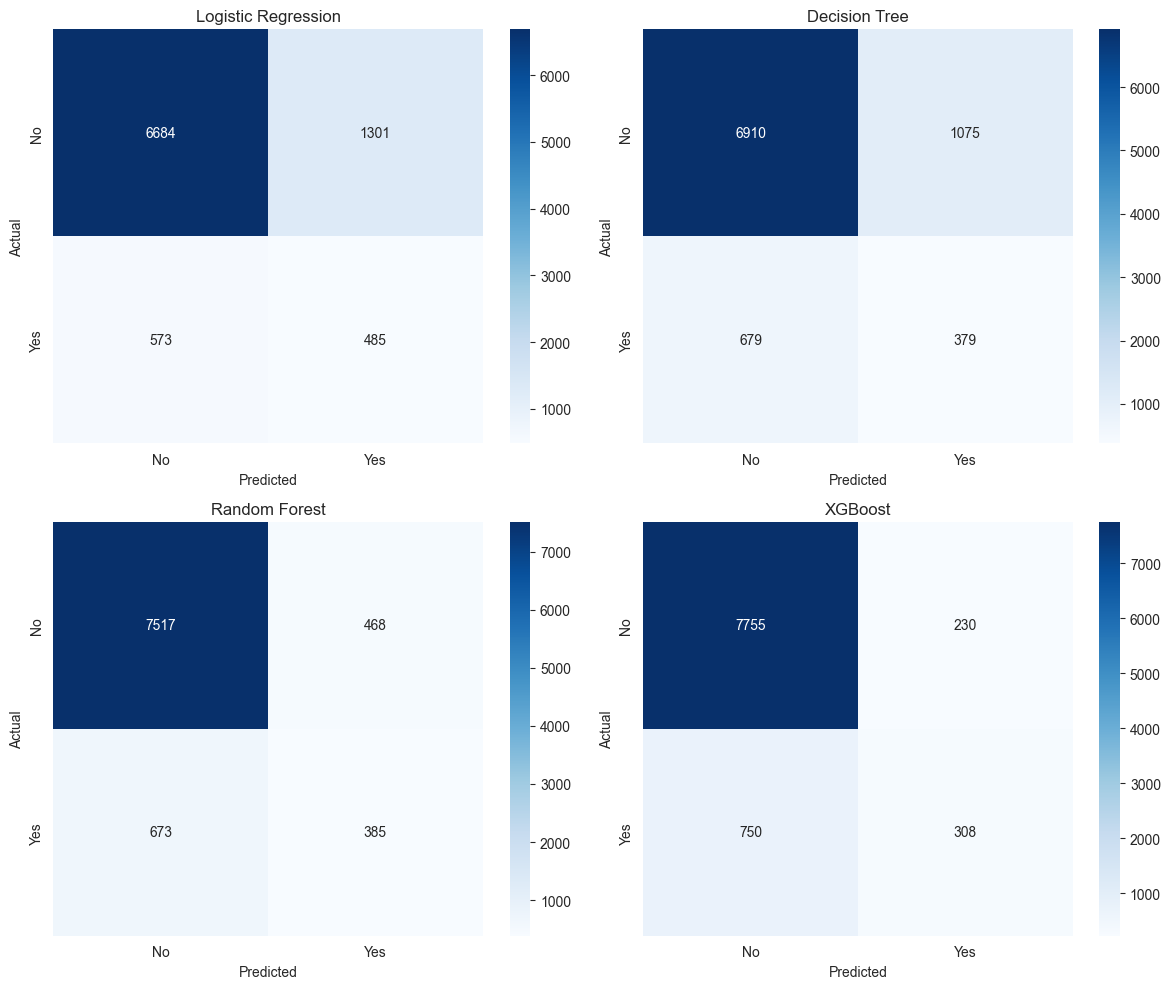

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results_dict.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 4.3 ROC Curves

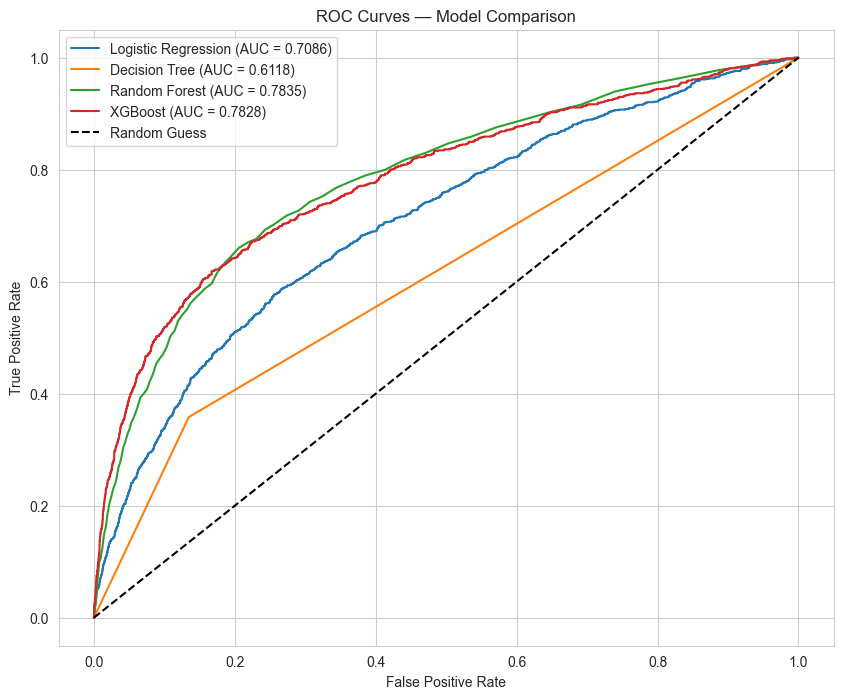

In [28]:
plt.figure(figsize=(10, 8))
for name, res in results_dict.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    auc_score = metrics_df.loc[name, 'ROC-AUC']
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curves — Model Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### 4.4 Precision-Recall Curves

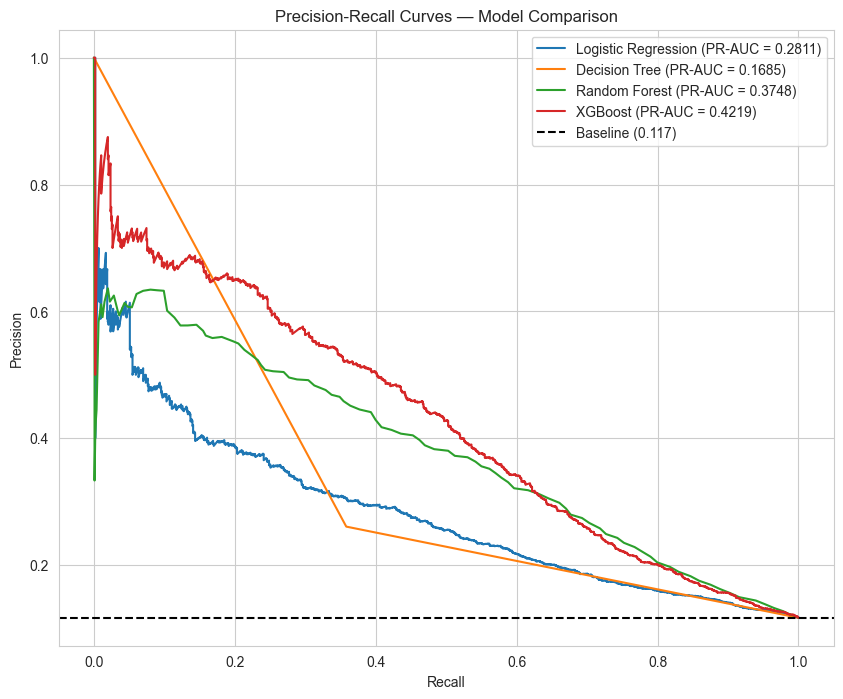

Comment: PR-AUC is more informative than ROC-AUC for imbalanced datasets because it focuses on the positive minority class.


In [29]:
plt.figure(figsize=(10, 8))
baseline = y_test.mean()

for name, res in results_dict.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    pr_auc = metrics_df.loc[name, 'PR-AUC']
    plt.plot(rec, prec, label=f"{name} (PR-AUC = {pr_auc:.4f})")

plt.axhline(y=baseline, color='k', linestyle='--', label=f'Baseline ({baseline:.3f})')
plt.title('Precision-Recall Curves — Model Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

print("Comment: PR-AUC is more informative than ROC-AUC for imbalanced datasets because it focuses on the positive minority class.")

### 4.5 Error Analysis

In [30]:
best_model_name = metrics_df.index[0]
best_res = results_dict[best_model_name]
y_pred_best = best_res['y_pred']

false_positives = (y_test == 0) & (y_pred_best == 1)
false_negatives = (y_test == 1) & (y_pred_best == 0)

print(f"--- Error Analysis for Best Model ({best_model_name}) ---")
print(f"False Positives (Predicted Subscribed, Actual Did Not): {false_positives.sum()}")
print(f"False Negatives (Predicted Did Not, Actual Subscribed): {false_negatives.sum()}")
print("\nNote: Detailed error analysis with original features would require mapping X_test back to original indices.")

--- Error Analysis for Best Model (Random Forest) ---
False Positives (Predicted Subscribed, Actual Did Not): 468
False Negatives (Predicted Did Not, Actual Subscribed): 673

Note: Detailed error analysis with original features would require mapping X_test back to original indices.


### 4.6 Best Model Selection

In [31]:
best_model_name = metrics_df.index[0]
y_pred_best = results_dict[best_model_name]['y_pred']
print(f"Best Model based on F1-Score: {best_model_name}")
print("\nJustification:")
print("1. F1-score balances precision (outreach spend quality) and recall (catching actual subscribers).")
print("2. PR-AUC is critical for highly imbalanced data as it measures precision-recall trade-offs on the positive class without being inflated by true negatives.")
print(f"3. {best_model_name} delivers the strongest balance between catching potential subscribers and minimizing costly wasted marketing calls.")
print("\nFinal Classification Report on Unseen Test Set:")
print(classification_report(y_test, y_pred_best))


Best Model based on F1-Score: Random Forest

Justification:
1. F1-score balances precision (outreach spend quality) and recall (catching actual subscribers).
2. PR-AUC is critical for highly imbalanced data as it measures precision-recall trade-offs on the positive class without being inflated by true negatives.
3. Random Forest delivers the strongest balance between catching potential subscribers and minimizing costly wasted marketing calls.

Final Classification Report on Unseen Test Set:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      7985
           1       0.45      0.36      0.40      1058

    accuracy                           0.87      9043
   macro avg       0.68      0.65      0.67      9043
weighted avg       0.86      0.87      0.87      9043



### 4.7 Feature Importance Analysis

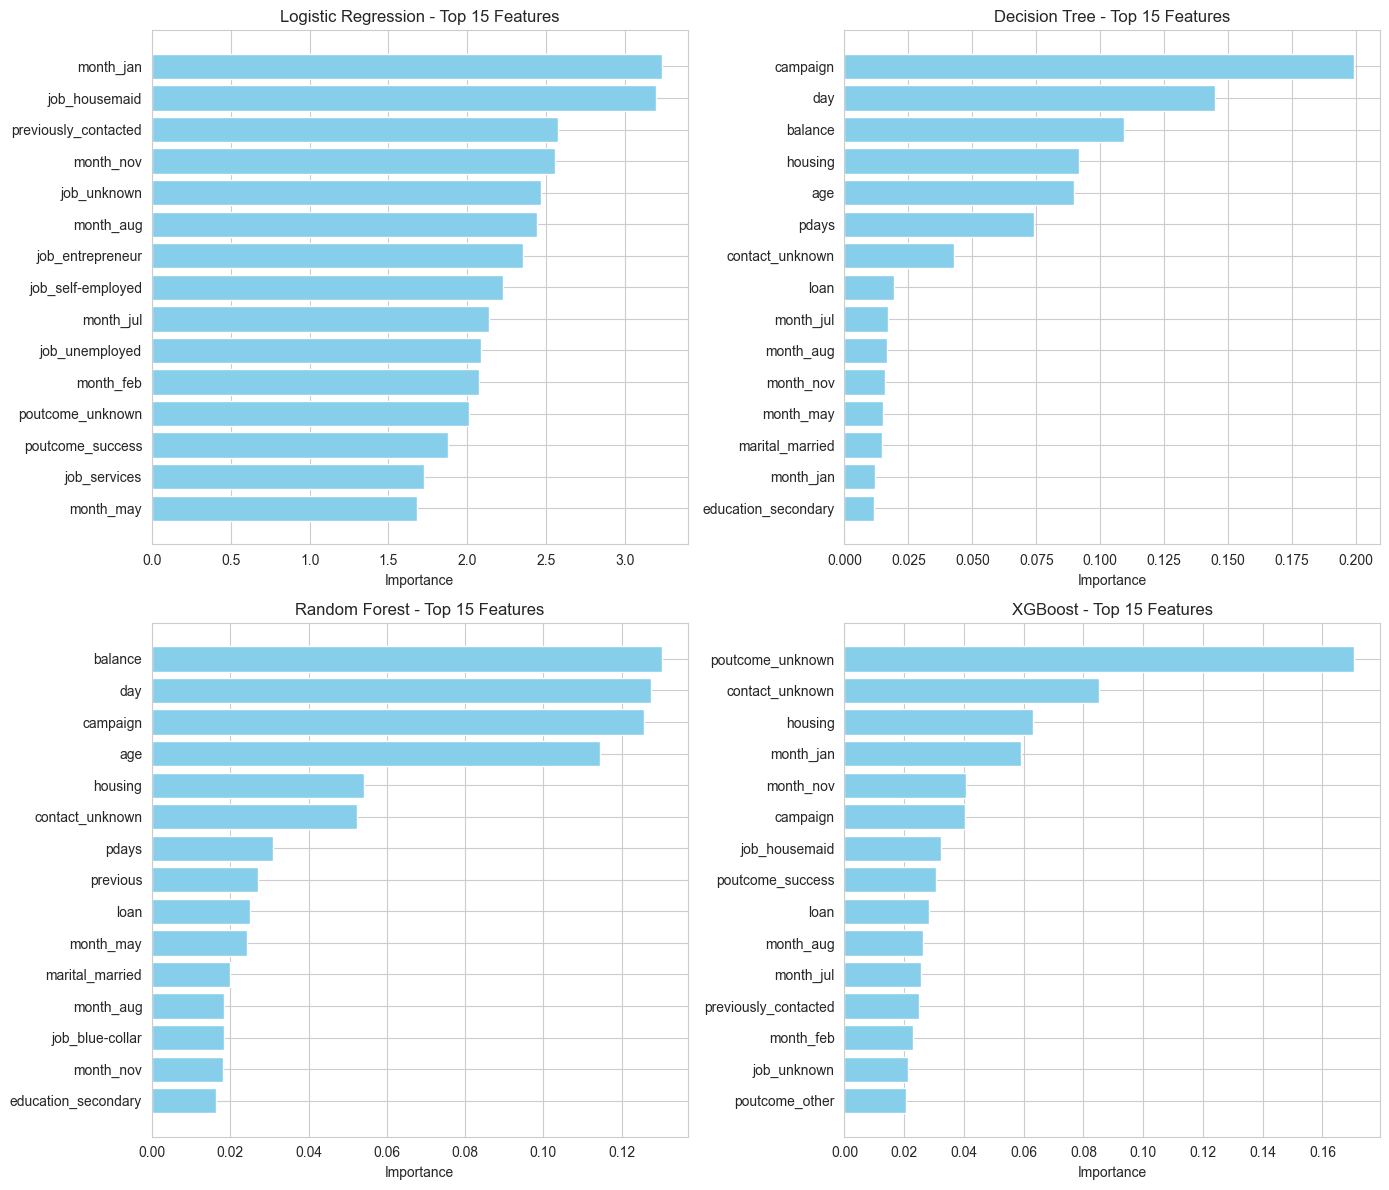

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
feature_names = X_test.columns

for i, (name, res) in enumerate(results_dict.items()):
    model = res['model']
    importances = None
    
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
        
    if importances is not None:
        feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=True).tail(15)
        axes[i].barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='skyblue')
        axes[i].set_title(f'{name} - Top 15 Features')
        axes[i].set_xlabel('Importance')
    else:
        axes[i].text(0.5, 0.5, 'Feature Importance Not Available', ha='center', va='center')
        axes[i].set_title(f'{name}')

plt.tight_layout()
plt.show()

### 4.8 High-Probability Customer Profile

In [33]:
print("--- High-Probability Customer Profile (Actual Subscribers) ---")
subscribers = original_data[original_data['y'] == 'yes']

print(f"Total Subscribers Analysed: {len(subscribers)}")
print("\nMost Common Traits:")
print(f"- Job Type: {subscribers['job'].mode()[0]}")
print(f"- Education Level: {subscribers['education'].mode()[0]}")
print(f"- Marital Status: {subscribers['marital'].mode()[0]}")
print(f"- Contact Method: {subscribers['contact'].mode()[0]}")
print(f"- Previous Outcome (poutcome): {subscribers['poutcome'].mode()[0]}")
print("\nKey Numerical Stats:")
print(f"- Age: Mean = {subscribers['age'].mean():.1f}, Median = {subscribers['age'].median():.1f}")
print(f"- Balance: Mean = {subscribers['balance'].mean():.1f}, Median = {subscribers['balance'].median():.1f}")

--- High-Probability Customer Profile (Actual Subscribers) ---
Total Subscribers Analysed: 5289

Most Common Traits:
- Job Type: management
- Education Level: secondary
- Marital Status: married
- Contact Method: cellular
- Previous Outcome (poutcome): unknown

Key Numerical Stats:
- Age: Mean = 41.7, Median = 38.0
- Balance: Mean = 1804.3, Median = 733.0


### 4.9 Business Recommendations

1. **Target customers with profiles matching the subscriber profile**: Focus on the most common traits identified (e.g., specific job types, education levels, and marital status) for higher conversion rates.
2. **Prioritise contact via cellular over telephone**: Cellular contacts historically yield a better response rate compared to landlines.
3. **Focus campaigns in months with historically higher subscription rates**: Optimize the timing of the marketing campaigns to align with peak historical performance.
4. **Allocate more resources to customers who responded positively in previous campaigns**: Customers with a `poutcome=success` have a significantly higher likelihood of subscribing again.
5. **Deprioritise customers with high campaign contact counts**: Avoid diminishing returns and customer annoyance by limiting the number of times a single customer is contacted during a campaign.

### 4.10 Limitations & Responsible AI Considerations

- **Model uncertainty**: Predictions generated by these models are probabilities and indicators of likelihood, not absolute certainties.
- **Demographic bias risk**: There is a risk that the model may inadvertently discriminate based on features like age, education, or marital status. Ongoing monitoring is essential.
- **Duration leakage**: The `duration` feature (call duration) was likely dropped for realistic predictive modelling (as it's only known after the call), which can lower apparent performance compared to flawed benchmarks.
- **Temporal/geographic limitations**: The dataset represents Portuguese banking data from 2008-2010. Consumer behavior may have changed, and the findings may not generalise to other countries or current economic climates.
- **Human-in-the-loop**: The model is a decision-support tool. It should augment, not replace, the nuanced decision-making of the marketing team.
- **Data privacy**: All customer data profiling and targeting must strictly adhere to current data privacy regulations (e.g., GDPR).